Carregando os dados...
Tamanho do Treino: 1280 amostras
Tamanho do Teste: 320 amostras

Treinando a Rede Neural (MLP)...

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

      Empate       0.67      0.29      0.40         7
    O venceu       0.93      1.00      0.96        63
    Tem jogo       0.96      0.91      0.93       125
    X venceu       0.96      1.00      0.98       125

    accuracy                           0.95       320
   macro avg       0.88      0.80      0.82       320
weighted avg       0.95      0.95      0.95       320



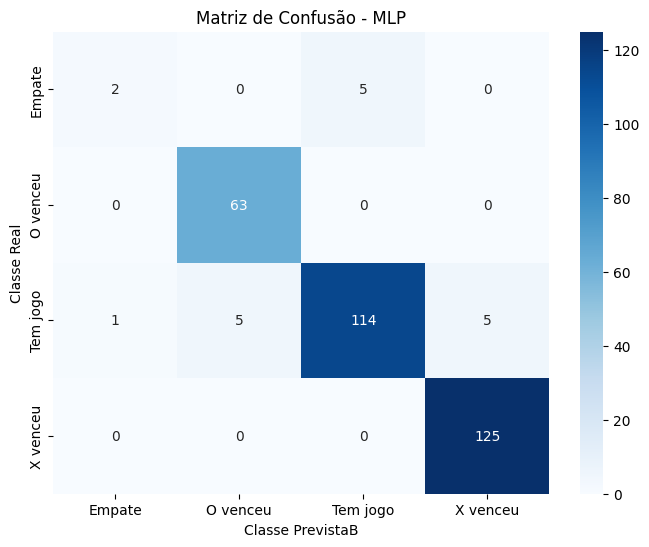

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print("Carregando os dados...")
df = pd.read_csv('../../data/processed/preprocessed_1.csv')

X = df.drop('classe', axis=1) # As 9 posições do tabuleiro
y = df['classe']              # As 4 classes

le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)


print(f"Tamanho do Treino: {len(X_train)} amostras")
print(f"Tamanho do Teste: {len(X_test)} amostras\n")

# 4. Criar a Arquitetura do MLP
print("Treinando a Rede Neural (MLP)...")

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), # 1ª camada com 64 neurônios, 2ª com 32
    activation='relu',           # Função de ativação não-linear
    solver='adam',               # Otimizador rápido e eficiente
    max_iter=1000,              
    random_state=42
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)


y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred) 


print("\n--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test_labels, y_pred_labels))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - MLP')
plt.ylabel('Classe Real')
plt.xlabel('Classe PrevistaB')
plt.show()

In [2]:
import joblib


joblib.dump(mlp, '../../models//MLP/mlp_model.pkl')
joblib.dump(le, '../../models//MLP/mlp_label_encoder.pkl')
print("Modelo e Encoder salvos com sucesso!")

Modelo e Encoder salvos com sucesso!
